This notebook illustrates the complete verification procedure of the phase masks by implementing beam propagation within the Tidy3D FDTD solver.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

import tidy3d as td
from tidy3d import web

Simulation pixel size:  199 199


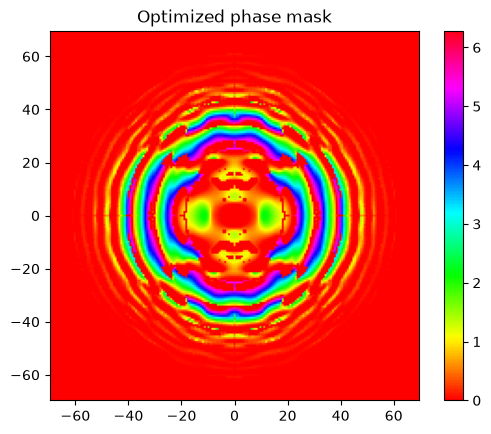

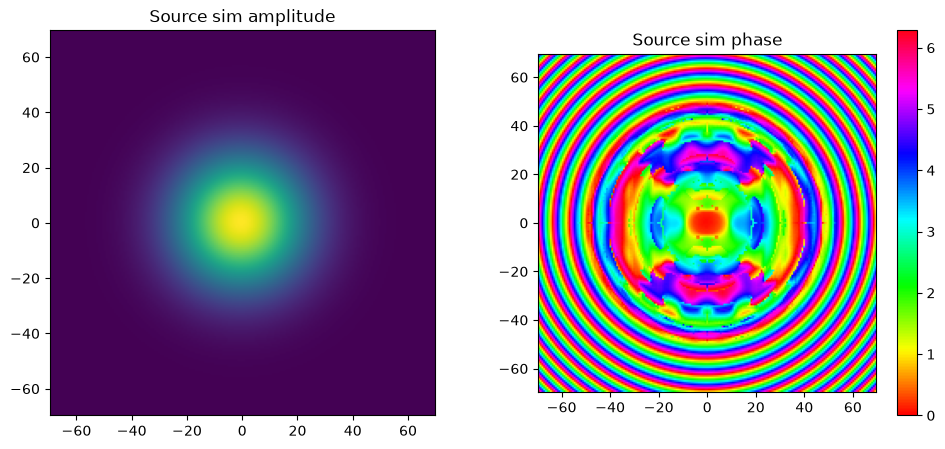

In [26]:
lambda0 = 1.55
freq0 = td.C_0 / lambda0
fwidth = freq0 / 10
min_steps_wavelength = 20

#simulation size
sim_x_size = 140 #x dimension [um]
sim_y_size = sim_x_size #y dimension [um]
sim_z_size = 3 * lambda0
P = 0.700 #unitcell pitch [um]
unit_cell_pitch = P #[um]
Nx = 1025 #x-number of pixels
Ny = Nx #y-number of pixels
nx = (Nx - 1) // 2 #indices without axes (= #512)
ny = (Ny - 1) // 2
n_siO2 = 1.45

#simulation run time
run_time = 20 / fwidth

#full spatial grid
size_x = unit_cell_pitch * Nx #actual physical size [um]
size_y = unit_cell_pitch * Ny
xs = np.arange(-Nx//2+1, Nx//2+1) * (size_x / Nx)
ys = np.arange(-Ny//2+1, Ny//2+1) * (size_y / Ny)
XS, YS = np.meshgrid(xs, ys)

#important checks on spatial grid
try:
    assert(len(xs) == Nx)
    assert(len(ys) == Ny)
    assert(xs[0] == xs[-1]*-1)
    assert(ys[0] == ys[-1]*-1)
    assert(xs[nx]==0)
    assert(ys[ny]==0)
    assert(np.abs(np.abs(xs[1]-xs[0]) - unit_cell_pitch) < 1e-12)
except:
    raise ValueError("Error while setting up the spatial grid.")

#defines the simulation spatial grid (which is smaller than the full spatial grid)
sim_mask = np.zeros((Nx, Ny),dtype=int)
for i in range(Nx):
    for j in range(Ny):
        if np.abs(XS[i,j])<sim_x_size/2 and np.abs(YS[i,j])<sim_y_size/2:
            sim_mask[i,j] = 1
        else:
            sim_mask[i,j] = 0

Nx_sim = int(np.sum(sim_mask, axis=1).max())
Ny_sim = Nx_sim
print("Simulation pixel size: ", Nx_sim, Ny_sim)
source_x_size = Nx_sim * P
source_y_size = source_x_size
xs_source = np.linspace(-source_x_size/2, source_x_size/2, Nx_sim)
ys_source = xs_source
XS_source, YS_source = np.meshgrid(xs_source, ys_source)

input_field = np.load("../results_sym/input_field.npy")
phase_mask1 = np.load("../results_sym/optimized_phase_mask_1.npy")

input_sim = input_field[sim_mask == 1].reshape((Nx_sim, Ny_sim))
phase_mask1_sim = np.exp(1j*phase_mask1[sim_mask == 1].reshape((Nx_sim, Ny_sim)))
source_sim = input_sim * phase_mask1_sim

plt.subplots()
phase_mask_sim_values = (phase_mask1[sim_mask == 1].reshape((Nx_sim, Ny_sim)) + 2*np.pi) % (2*np.pi)
plt.imshow(phase_mask_sim_values, extent=(-source_x_size/2, source_x_size/2, -source_y_size/2, source_y_size/2), cmap='hsv')
plt.clim(0, 2*np.pi)
plt.colorbar()
plt.title("Optimized phase mask")
plt.show()

plt.subplots(1,2, figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(np.abs(source_sim), extent=(-source_x_size/2, source_x_size/2, -source_y_size/2, source_y_size/2))
plt.title("Source sim amplitude")
plt.subplot(1,2,2)
plt.imshow((np.angle(source_sim)+2*np.pi)%(2*np.pi), extent=(-source_x_size/2, source_x_size/2, -source_y_size/2, source_y_size/2), cmap='hsv')
plt.colorbar()
plt.clim(0, 2*np.pi)
plt.title("Source sim phase")
plt.show()

In [27]:
#grid setup
grid_spec = td.GridSpec.auto(wavelength=lambda0, min_steps_per_wvl=min_steps_wavelength)

#GaussianBeam source
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth)

source_position = -lambda0
src_monitor_position = source_position

d0 = 353 #[um]
d1 = 218 #[um]
prj_monitor_position = lambda0

dataset_input_EH = td.FieldDataset(
    Ex = td.ScalarFieldDataArray(
        source_sim[..., None, None],
        coords={
            "x": xs_source,
            "y": ys_source,
            "z": [source_position],
            "f": [freq0],
        },
    ),
    Hy = td.ScalarFieldDataArray(
        source_sim[..., None, None] / td.ETA_0,
        coords={
            "x": xs_source,
            "y": ys_source,
            "z": [source_position],
            "f": [freq0],
        },
    ),
)

#flux monitors
mnt_flux_f_pos = source_position + 0.5
mnt_flux_f = td.FluxMonitor(
    center=(0, 0, mnt_flux_f_pos), 
    size=(td.inf, td.inf, 0), 
    freqs=[freq0], 
    name="flux_f"
)
mnt_flux_b_pos = source_position - 0.5
mnt_flux_b = td.FluxMonitor(
    center=(0, 0, mnt_flux_b_pos), 
    size=(td.inf, td.inf, 0), 
    freqs=[freq0], 
    name="flux_b"
)

#source field monitor
mnt_src = td.FieldMonitor(
    center=(0,0,src_monitor_position),
    size=(source_x_size,source_y_size,0),
    freqs=[freq0],
    colocate=False,
    name="monitor_src",
)

#near field monitor
mnt_nf = td.FieldMonitor(
    center=(0,0,prj_monitor_position),
    size=(source_x_size,source_y_size,0),
    freqs=[freq0],
    colocate=False,
    name="monitor_nf",
)

#far-field projection monitor
f = d1
#far-field space grid
xs_far = np.linspace(-source_x_size/2, source_x_size/2, Nx_sim)
ys_far = np.linspace(-source_y_size/2, source_y_size/2, Ny_sim)

mnt_prj = td.FieldProjectionCartesianMonitor(
    center=[0,0,prj_monitor_position],
    size=[source_x_size,source_y_size,0],
    freqs=[freq0],
    name="monitor_projection",
    proj_axis=2, #axis along which the projection plane is oriented
    proj_distance=f,
    x=xs_far,
    y=ys_far,
    custom_origin=(0,0,source_position),
    far_field_approx=False,
)

# Monitor for propagation
mnt_yz = td.FieldMonitor(
    center=(0, 0, 0), 
    size=(0, sim_y_size, sim_z_size), 
    freqs=[freq0], 
    name="field_yz",
)

#custom source
custom_src = td.CustomFieldSource(
    source_time = source_time,
    center = (0,0,source_position),
    size = (source_x_size,source_y_size,0),
    field_dataset = dataset_input_EH
)

all_monitors = [mnt_flux_f, mnt_flux_b, mnt_src, mnt_nf, mnt_prj, mnt_yz]

In [ ]:
sim_size = [sim_x_size, sim_y_size, sim_z_size]
sim = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    sources=[custom_src],
    monitors=all_monitors,
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)
sim.plot(x=0)
plt.savefig("full_verification_results/simulation_setup.pdf")
plt.show()

In [ ]:
job = web.Job(simulation=sim, task_name="full_verification_step1")
estimated_cost = web.estimate_cost(job.task_id)

In [ ]:
sim_data = job.run(path="full_verification_results/full_verification_step1.hdf5")

# Load the job metadata from file.
#job_loaded = web.Job.from_file("data/job_asm_verify.json")

# Download the data from the server and load it into a SimulationData object.
#sim_data = job_loaded.load(path="data/asm_verify.hdf5")

In [31]:
# Saves the job metadata to a single file.
job.to_file("full_verification_results/full_verification_step1.hdf5")

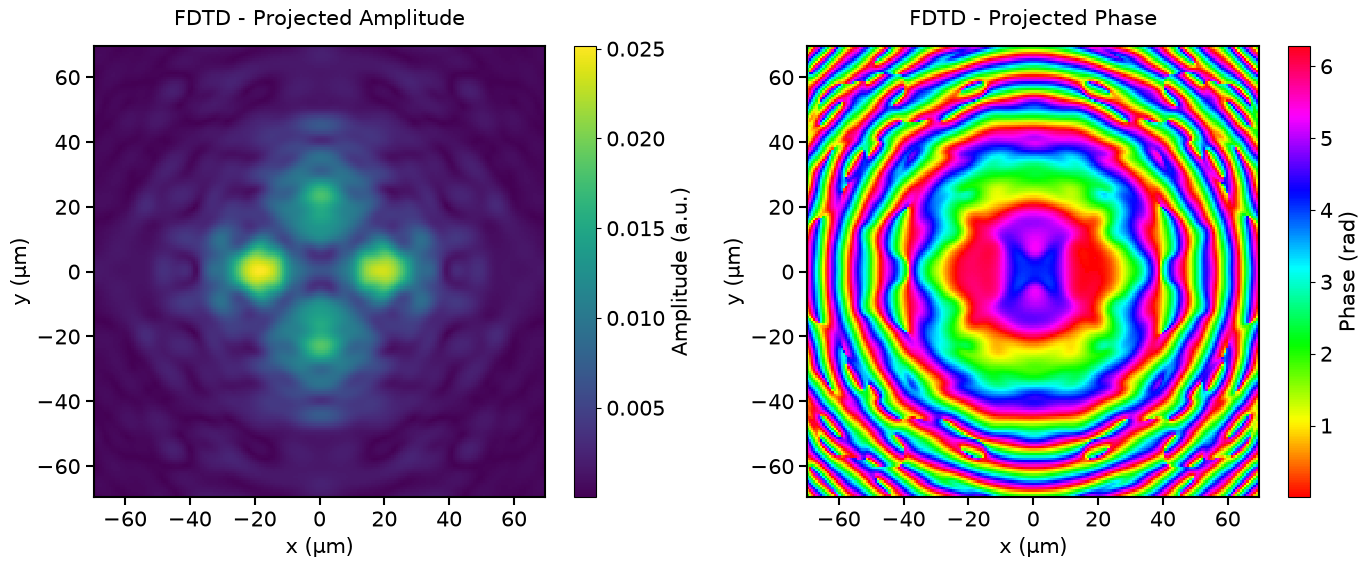

In [60]:
#Projected field monitor
proj_fields = sim_data["monitor_projection"].fields_cartesian.Ex.sel(f=freq0, z=f)

fig, ax = plt.subplots(1,2,figsize=(14, 5.5),)

im0 = ax[0].pcolormesh(XS_source, YS_source, np.abs(proj_fields), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[0].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("y (μm)", fontsize=15,)
ax[0].set_title("FDTD - Projected Amplitude", fontsize=15, pad=15)
ax[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=ax[0], label="Amplitude (a.u.)")
cbar0.set_label("Amplitude (a.u.)", fontsize=15)
cbar0.ax.tick_params(labelsize=15)

im1 = ax[1].pcolormesh(XS_source, YS_source, (np.angle(proj_fields)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[1].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[1].set_title("FDTD - Projected Phase", fontsize=15, pad=15)
ax[1].set_xlabel("x (μm)", fontsize=15,)
ax[1].set_ylabel("y (μm)", fontsize=15,)
ax[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax[1], label="Phase (rad)")
cbar1.set_label("Phase (rad)", fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

nf_fields_x = sim_data["monitor_nf"].Ex.sel(f=freq0, z=prj_monitor_position).x
nf_fields_y = sim_data["monitor_nf"].Ex.sel(f=freq0, z=prj_monitor_position).y
nf_fields_Ex = sim_data["monitor_nf"].Ex.sel(f=freq0, z=prj_monitor_position)

plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/fdtd_intermediate_field.pdf")
plt.close()


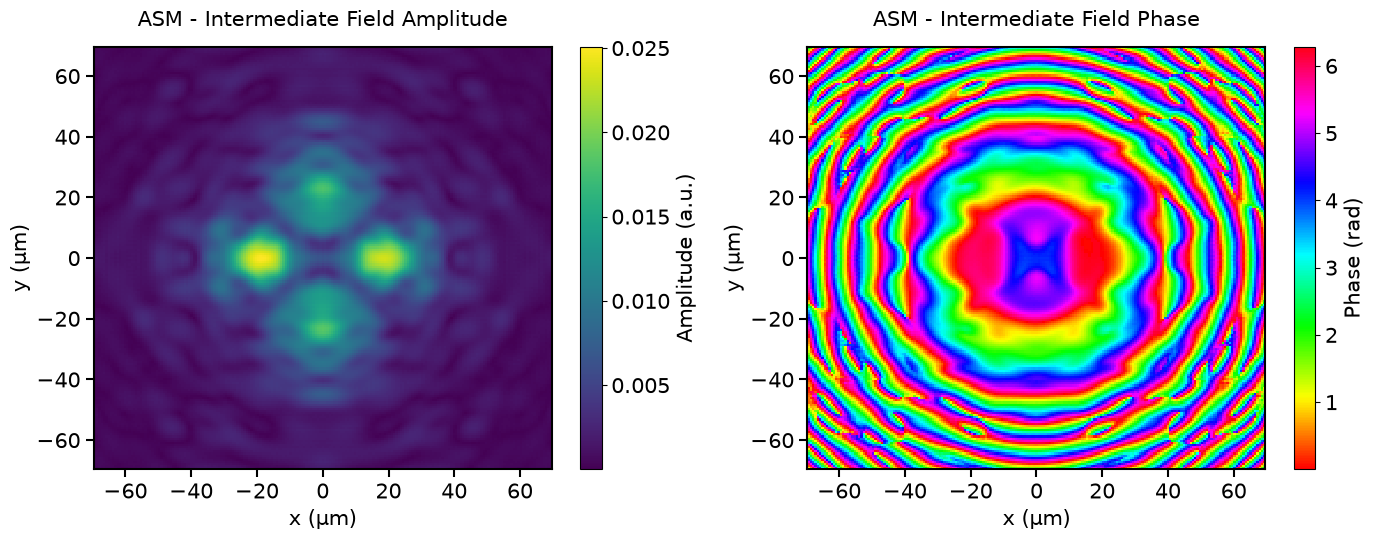

In [61]:
#Intermediate field computed by ASM
#import the ASM intermediate field
intermediate_field = np.load("../results_sym/intermediate_field_1.npy")

fig, ax = plt.subplots(1,2,figsize=(14, 5.5),)
im0 = ax[0].pcolormesh(XS, YS, np.abs(intermediate_field), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[0].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("y (μm)", fontsize=15,)
ax[0].set_title("ASM - Intermediate Field Amplitude", fontsize=15, pad=15)
cbar0 = plt.colorbar(im0, ax=ax[0], label="Amplitude (a.u.)")
cbar0.set_label("Amplitude (a.u.)", fontsize=15)
cbar0.ax.tick_params(labelsize=15)

im1 = ax[1].pcolormesh(XS, YS, (np.angle(intermediate_field)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[1].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[1].set_xlabel("x (μm)", fontsize=15,)
ax[1].set_ylabel("y (μm)", fontsize=15,)
ax[1].set_title("ASM - Intermediate Field Phase", fontsize=15, pad=15)
cbar1 = plt.colorbar(im1, ax=ax[1], label="Phase (rad)")
cbar1.set_label("Phase (rad)", fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/asm_intermediate_field.pdf")
plt.close()

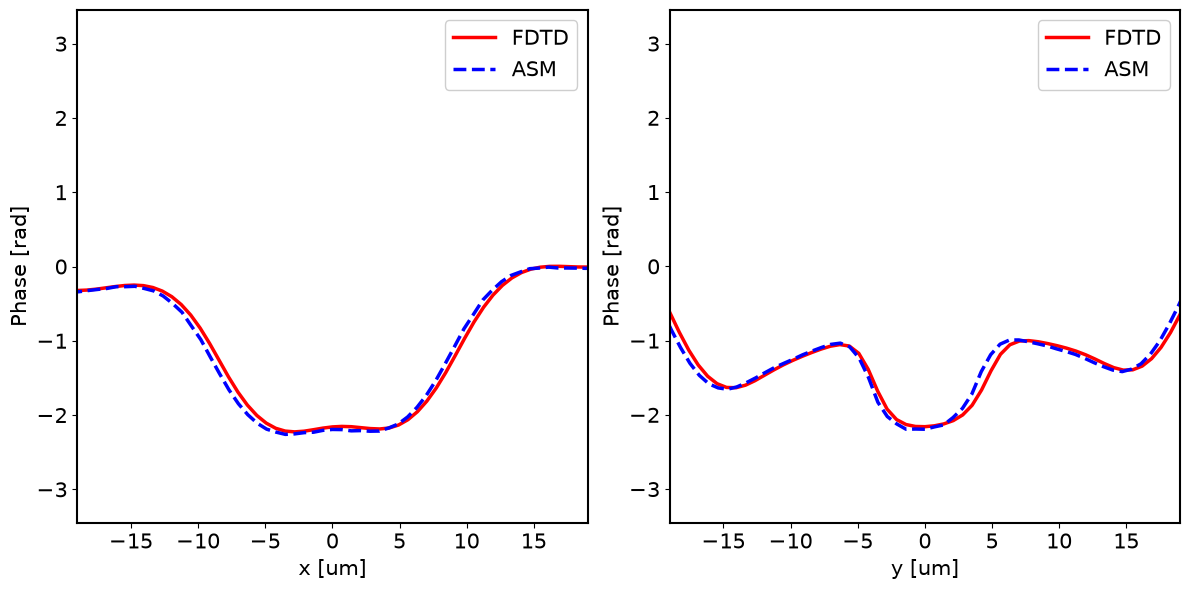

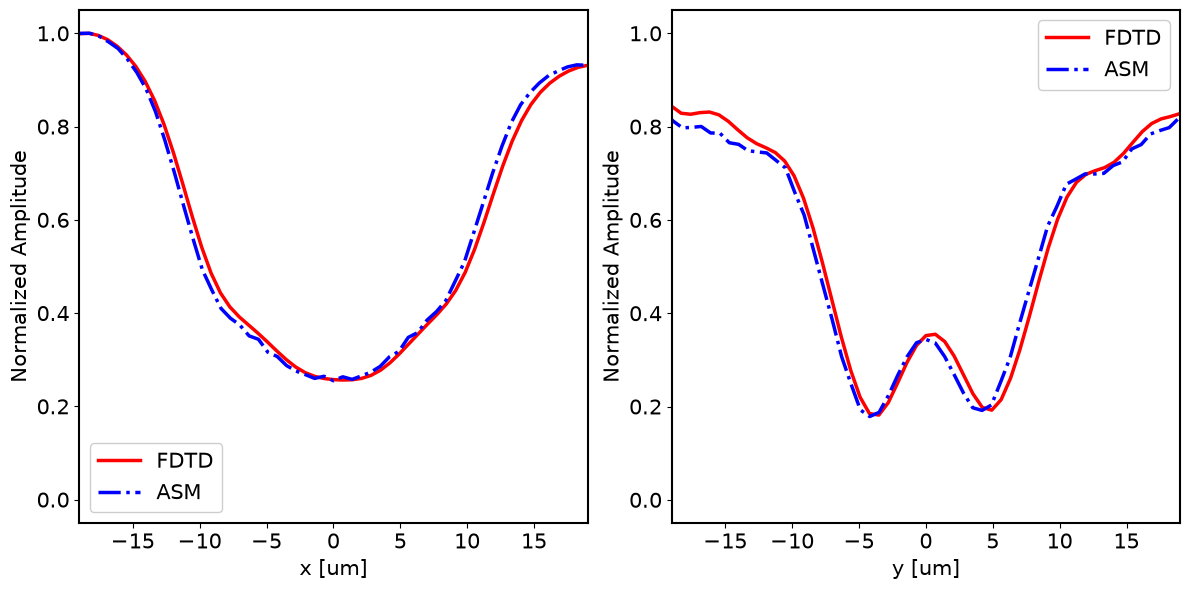

In [62]:
#make a 1D slice to compare phase of projected and intermediate ASM fields
#phase
output_fiber_core_diameter = 19

projected_field_slice_x = proj_fields.x
projected_field_slice_xCut = proj_fields[XS_source.shape[0]//2, :]
projected_field_slice_y = proj_fields.y
projected_field_slice_yCut = proj_fields[:,YS_source.shape[0]//2]

intermediate_field_slice_xCut = intermediate_field[XS.shape[0]//2,:]
intermediate_field_slice_x = XS[XS.shape[0]//2,:]
intermediate_field_slice_yCut = intermediate_field[:,YS.shape[0]//2]
intermediate_field_slice_y = YS[:,YS.shape[0]//2]

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(projected_field_slice_x, ((np.angle(projected_field_slice_xCut))),'r', label="FDTD", linewidth=2.5)
ax[0].plot(intermediate_field_slice_x, ((np.angle(intermediate_field_slice_xCut))),'--b', label="ASM", linewidth=2.5)
ax[0].set_xlabel("x [um]",fontsize=15,)
ax[0].set_ylabel("Phase [rad]",fontsize=15,)
ax[0].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[0].tick_params(labelsize=15)
ax[0].legend(fontsize=15, loc='best', framealpha=0.95)


ax[1].plot(projected_field_slice_y, ((np.angle(projected_field_slice_yCut))),'r', label="FDTD", linewidth=2.5)
ax[1].plot(intermediate_field_slice_y, ((np.angle(intermediate_field_slice_yCut))),'--b', label="ASM", linewidth=2.5)
ax[1].set_xlabel("y [um]", fontsize=15,)
ax[1].set_ylabel("Phase [rad]", fontsize=15,)
ax[1].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[1].tick_params(labelsize=15)
ax[1].legend(fontsize=15, loc='best', framealpha=0.95)

for ax_item in ax:
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)
plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/fdtd_vs_asm_intermediate_field_phase.pdf")
plt.close()

#amplitudes
normalized_projected_field_xCut = np.abs(projected_field_slice_xCut) / np.max(np.abs(projected_field_slice_xCut))
normalized_intermediate_field_xCut = np.abs(intermediate_field_slice_xCut) / np.max(np.abs(intermediate_field_slice_xCut))
normalized_projected_field_yCut = np.abs(projected_field_slice_yCut) / np.max(np.abs(projected_field_slice_yCut))
normalized_intermediate_field_yCut = np.abs(intermediate_field_slice_yCut) / np.max(np.abs(intermediate_field_slice_yCut))

fig, ax = plt.subplots(1,2,figsize=(12,6))
ax[0].plot(projected_field_slice_x, normalized_projected_field_xCut,'r', label="FDTD", linewidth=2.5)
ax[0].plot(intermediate_field_slice_x, normalized_intermediate_field_xCut,'-.b', label="ASM", linewidth=2.5)
ax[0].set_xlabel("x [um]", fontsize=15,)
ax[0].set_ylabel("Normalized Amplitude", fontsize=15,)
ax[0].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[0].tick_params(labelsize=15)
ax[0].legend(fontsize=15, loc='best', framealpha=0.95)
ax[1].plot(projected_field_slice_y, normalized_projected_field_yCut,'r', label="FDTD", linewidth=2.5)
ax[1].plot(intermediate_field_slice_y, normalized_intermediate_field_yCut,'-.b', label="ASM", linewidth=2.5)
ax[1].set_xlabel("y [um]", fontsize=15,)
ax[1].set_ylabel("Normalized Amplitude", fontsize=15,)
ax[1].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[1].tick_params(labelsize=15)
ax[1].legend(fontsize=15, loc='best', framealpha=0.95)
for ax_item in ax:
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)
plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/fdtd_vs_asm_intermediate_field_amplitude.pdf")
plt.close()

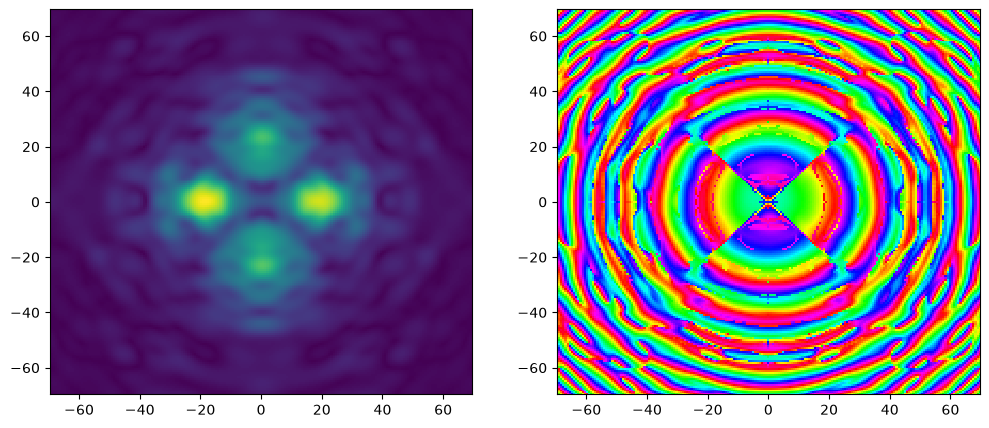

In [50]:
#the projected field represents the field just before the second metasurface.
#To compute the field after the second metasurface, we need the second metasurface phase mask.
#The resulting field, the product between field and phase mask, will then need to be propagated 
#up to the output plane.
phase_mask2 = np.load("../results_sym/optimized_phase_mask_2.npy")
phase_mask2_sim = phase_mask2[sim_mask==1].reshape((Nx_sim, Ny_sim))

field_after_ms2 = proj_fields.data * np.exp(1j*phase_mask2_sim)

#make a subplot of the field after the second metasurface amplitude and phase
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].pcolormesh(XS_source, YS_source, np.abs(field_after_ms2), shading='auto',rasterized=True)
ax[0].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[0].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[1].pcolormesh(XS_source, YS_source, (np.angle(field_after_ms2)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[1].set_ylim([-source_y_size / 2, source_y_size / 2])
plt.show()


In [51]:
#second simulation setup
medium_impedance = td.ETA_0 / n_siO2

dataset_input_MS2_EH = td.FieldDataset(
    Ex = td.ScalarFieldDataArray(
        field_after_ms2[..., None, None],
        coords={
            "x": xs_source,
            "y": ys_source,
            "z": [source_position],
            "f": [freq0],
        },
    ),
    Hy = td.ScalarFieldDataArray(
        field_after_ms2[..., None, None] / medium_impedance,
        coords={
            "x": xs_source,
            "y": ys_source,
            "z": [source_position],
            "f": [freq0],
        },
    ),
)

custom_src_MS2 = td.CustomFieldSource(
    source_time = source_time,
    center = (0,0,source_position),
    size = (source_x_size,source_y_size,0),
    field_dataset = dataset_input_MS2_EH
)

#far-field projection monitor
f2 = d0 #recall that we assumed d0=d2

mnt_prj_MS2 = td.FieldProjectionCartesianMonitor(
    center=[0,0,prj_monitor_position],
    size=[source_x_size,source_y_size,0],
    freqs=[freq0],
    name="monitor_projection_MS2",
    proj_axis=2, #axis along which the projection plane is oriented
    proj_distance=f2,
    x=xs_far,
    y=ys_far,
    custom_origin=(0,0,source_position),
    far_field_approx=False,
)

all_monitors2 = [mnt_flux_f, mnt_flux_b, mnt_src, mnt_nf, mnt_prj_MS2, mnt_yz]

In [ ]:
sim2 = td.Simulation(
    size=sim_size,
    grid_spec=grid_spec,
    sources=[custom_src_MS2],
    monitors=all_monitors2,
    run_time=run_time,
    medium=td.Medium(permittivity=n_siO2**2),
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.PML()),
)
sim2.plot(x=0)
#plt.savefig("full_verification_results/full_verification_step2.pdf")
plt.show()

job_MS2 = web.Job(simulation=sim2, task_name="full_verification_step2")
estimated_cost = web.estimate_cost(job_MS2.task_id)

In [ ]:
sim_data_MS2 = job_MS2.run(path="full_verification_results/full_verification_step2.hdf5")

# Saves the job metadata to a single file.
#job_MS2.to_file("full_verification_results/full_verification_step2.hdf5")

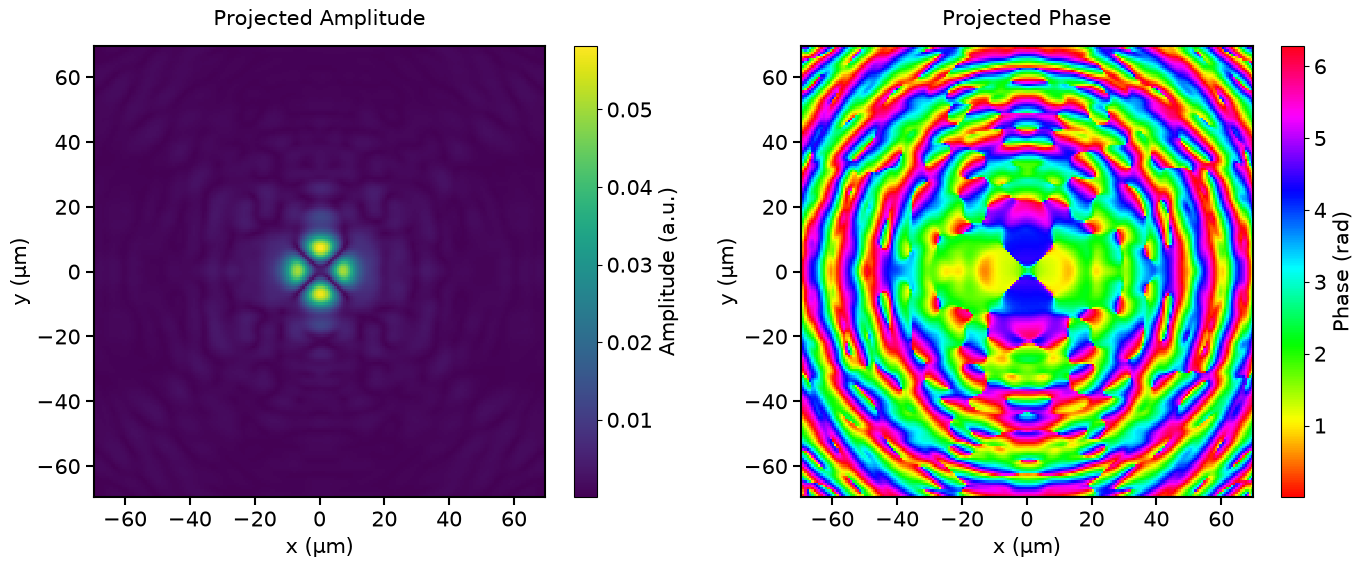

In [64]:
#Projected field monitor
proj_fields_MS2 = sim_data_MS2["monitor_projection_MS2"].fields_cartesian.Ex.sel(f=freq0, z=d0)

fig, ax = plt.subplots(1,2,figsize=(14, 5.5),)
im0 = ax[0].pcolormesh(XS_source, YS_source, np.abs(proj_fields_MS2), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[0].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("y (μm)", fontsize=15,)
ax[0].set_title("Projected Amplitude", fontsize=15, pad=15)
ax[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=ax[0], label="Amplitude (a.u.)")
cbar0.set_label("Amplitude (a.u.)", fontsize=15)
cbar0.ax.tick_params(labelsize=15)

im1 = ax[1].pcolormesh(XS_source, YS_source, (np.angle(proj_fields_MS2)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[1].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[1].set_xlabel("x (μm)", fontsize=15,)
ax[1].set_ylabel("y (μm)", fontsize=15,)
ax[1].set_title("Projected Phase", fontsize=15, pad=15)
ax[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax[1], label="Phase (rad)")
cbar1.set_label("Phase (rad)", fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)
plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/fdtd_output_field.pdf")
plt.close()

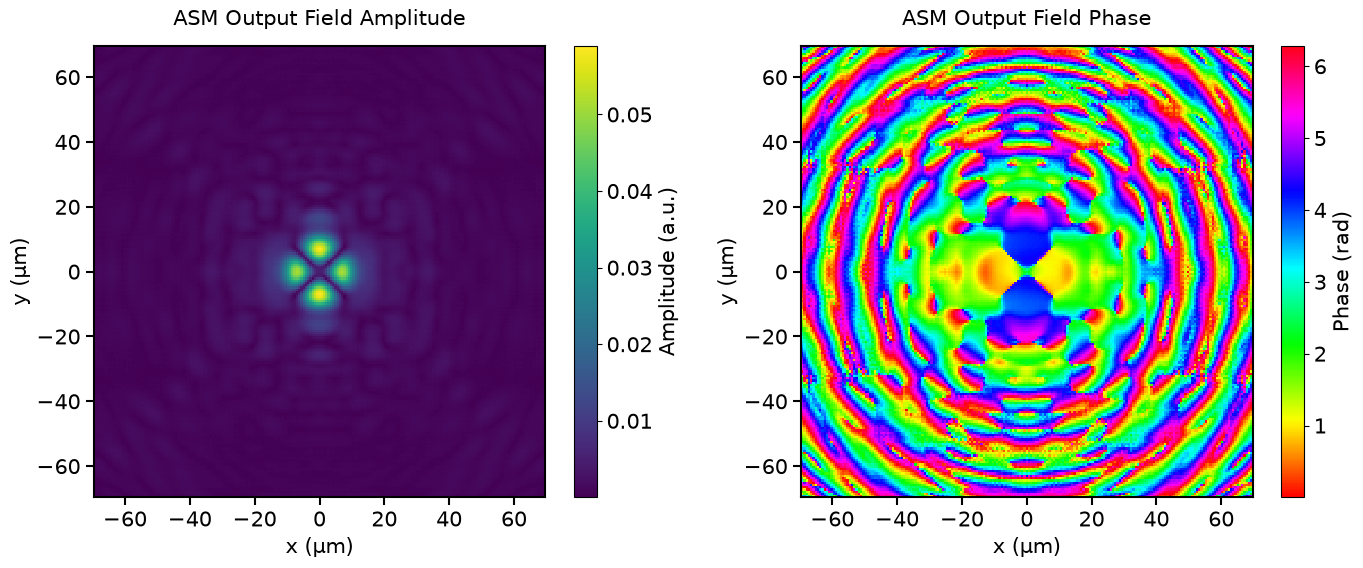

In [65]:
#output field computed by ASM
#import the ASM output field
asm_output_field = np.load("../results_sym/optimized_output_field.npy")

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5),)

# Amplitude plot
im0 = ax[0].pcolormesh(XS, YS, np.abs(asm_output_field), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[0].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[0].set_xlabel('x (μm)', fontsize=15,)
ax[0].set_ylabel('y (μm)', fontsize=15,)
ax[0].set_title("ASM Output Field Amplitude", fontsize=15, pad=15)
ax[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=ax[0], label='Amplitude (a.u.)')
cbar0.set_label('Amplitude (a.u.)', fontsize=15)
cbar0.ax.tick_params(labelsize=15)

# Phase plot
im1 = ax[1].pcolormesh(XS, YS, (np.angle(asm_output_field)+2*np.pi)%(2*np.pi), 
                        shading='auto', cmap='hsv',rasterized=True)
ax[1].set_xlim([-source_x_size / 2, source_x_size / 2])
ax[1].set_ylim([-source_y_size / 2, source_y_size / 2])
ax[1].set_xlabel('x (μm)', fontsize=15,)
ax[1].set_ylabel('y (μm)', fontsize=15,)
ax[1].set_title("ASM Output Field Phase", fontsize=15, pad=15)
ax[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax[1], label='Phase (rad)')
cbar1.set_label('Phase (rad)', fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/asm_output_field.pdf")
plt.close()

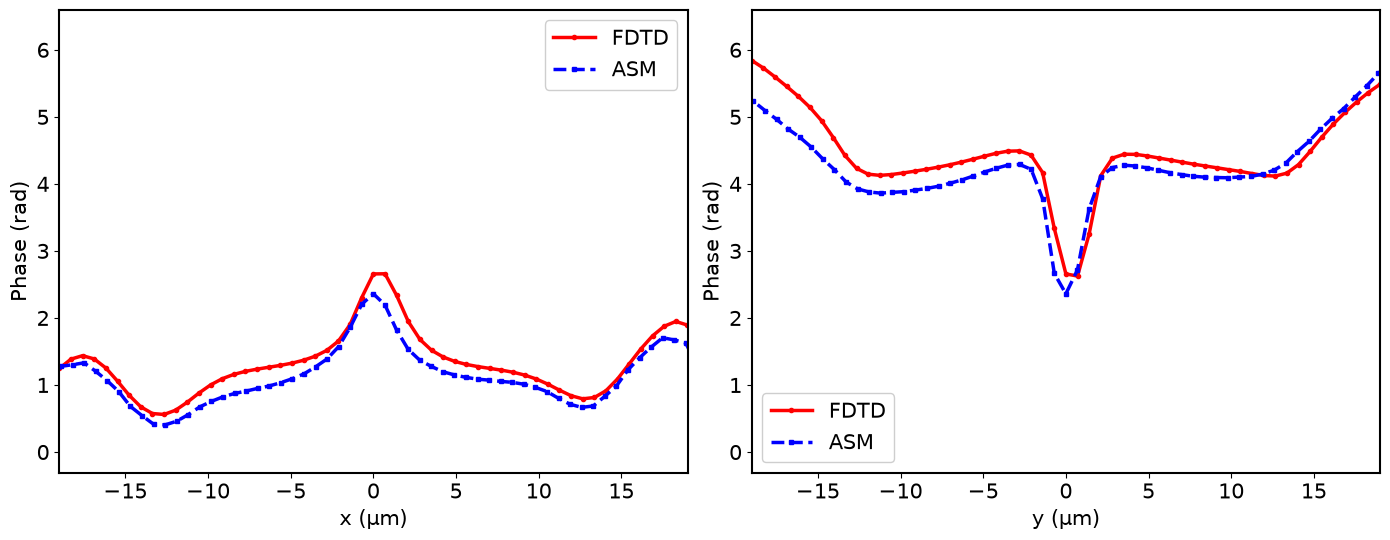

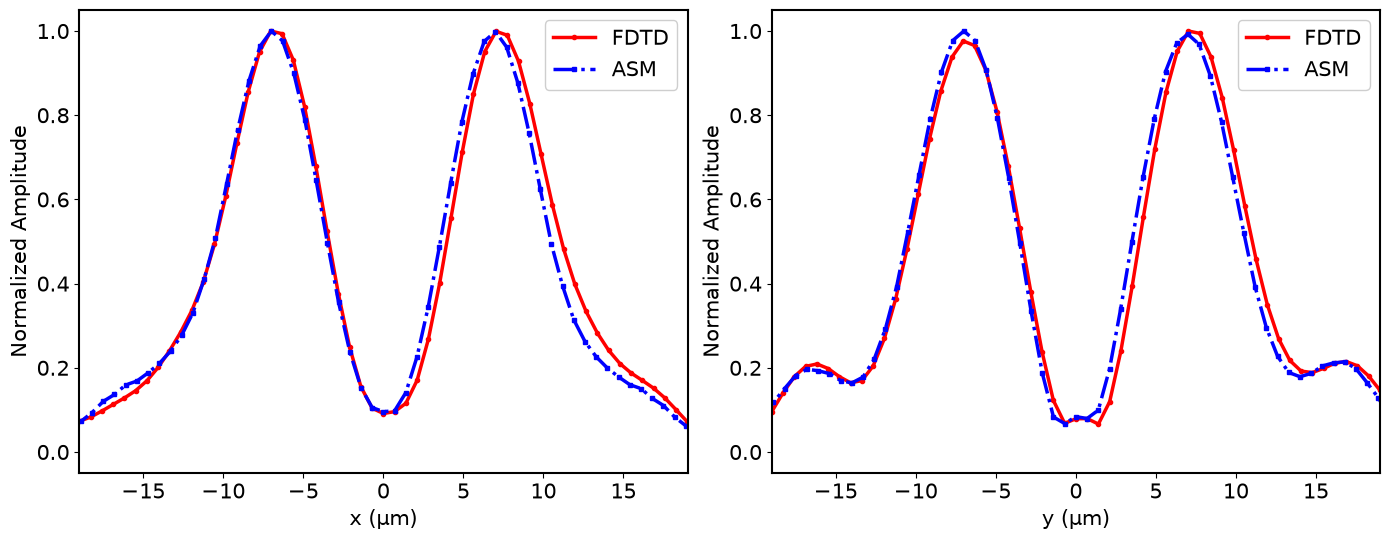

In [66]:
#make a 1D slice to compare phase of projected and intermediate ASM fields
#phase
projected_field_MS2_slice_x = proj_fields_MS2.x
projected_field_MS2_slice_xCut = proj_fields_MS2[XS_source.shape[0]//2, :]
projected_field_MS2_slice_y = proj_fields_MS2.y
projected_field_MS2_slice_yCut = proj_fields_MS2[:,YS_source.shape[0]//2]

asm_output_field_slice_xCut = asm_output_field[XS.shape[0]//2,:]
asm_output_field_slice_x = XS[XS.shape[0]//2,:]
asm_output_field_slice_yCut = asm_output_field[:,YS.shape[0]//2]
asm_output_field_slice_y = YS[:,YS.shape[0]//2]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].plot(projected_field_MS2_slice_x, (np.angle(projected_field_MS2_slice_xCut)+2*np.pi)%(2*np.pi),
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[0].plot(asm_output_field_slice_x, (np.angle(asm_output_field_slice_xCut)+2*np.pi)%(2*np.pi),
           '--b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("Phase (rad)", fontsize=15,)
ax[0].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[0].tick_params(labelsize=15)
ax[0].legend(fontsize=15, loc='best', framealpha=0.95)


ax[1].plot(projected_field_MS2_slice_y, (np.angle(projected_field_MS2_slice_yCut)+2*np.pi)%(2*np.pi),
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[1].plot(asm_output_field_slice_y, (np.angle(asm_output_field_slice_yCut)+2*np.pi)%(2*np.pi),
           '--b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[1].set_xlabel("y (μm)", fontsize=15,)
ax[1].set_ylabel("Phase (rad)", fontsize=15,)
ax[1].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[1].tick_params(labelsize=15)
ax[1].legend(fontsize=15, loc='best', framealpha=0.95)


for ax_item in ax:
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/fdtd_vs_asm_output_field_phase.pdf")
plt.close()

#amplitudes
normalized_projected_field_MS2_xCut = np.abs(projected_field_MS2_slice_xCut) / np.max(np.abs(projected_field_MS2_slice_xCut))
normalized_asm_output_field_xCut = np.abs(asm_output_field_slice_xCut) / np.max(np.abs(asm_output_field_slice_xCut))
normalized_projected_field_MS2_yCut = np.abs(projected_field_MS2_slice_yCut) / np.max(np.abs(projected_field_MS2_slice_yCut))
normalized_asm_output_field_yCut = np.abs(asm_output_field_slice_yCut) / np.max(np.abs(asm_output_field_slice_yCut))

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].plot(projected_field_MS2_slice_x, normalized_projected_field_MS2_xCut,
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[0].plot(asm_output_field_slice_x, normalized_asm_output_field_xCut,
           '-.b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("Normalized Amplitude", fontsize=15,)
ax[0].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[0].tick_params(labelsize=15)
ax[0].legend(fontsize=15, loc='best', framealpha=0.95)


ax[1].plot(projected_field_MS2_slice_y, normalized_projected_field_MS2_yCut,
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[1].plot(asm_output_field_slice_y, normalized_asm_output_field_yCut,
           '-.b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[1].set_xlabel("y (μm)", fontsize=15,)
ax[1].set_ylabel("Normalized Amplitude", fontsize=15,)
ax[1].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[1].tick_params(labelsize=15)
ax[1].legend(fontsize=15, loc='best', framealpha=0.95)


for ax_item in ax:
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
#plt.savefig("full_verification_results/fdtd_vs_asm_output_field_amplitude.pdf")
plt.close()